In [1]:
print("Hola TechMind")

Hola TechMind


In [2]:
import pandas as pd
from pathlib import Path

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Dataset cargado correctamente
Filas: 301
Columnas: 3


In [4]:
df["categoria"].value_counts()

categoria
Bases de Datos      72
Cloud               69
Machine Learning    37
Backend             35
Frontend            27
Data Science        27
Cybersecurity       21
DevOps              13
Name: count, dtype: int64

verificar la calidad básica

In [5]:
print("Valores nulos:")
print(df.isnull().sum())

print("\nDuplicados completos:")
print(df.duplicated().sum())

print("\nTextos duplicados:")
print(df["texto"].duplicated().sum())

Valores nulos:
titulo       0
texto        0
categoria    0
dtype: int64

Duplicados completos:
0

Textos duplicados:
0


In [6]:
category_counts = df["categoria"].value_counts()

print(category_counts)

categoria
Bases de Datos      72
Cloud               69
Machine Learning    37
Backend             35
Frontend            27
Data Science        27
Cybersecurity       21
DevOps              13
Name: count, dtype: int64


In [7]:
category_percentages = (
    df["categoria"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(category_percentages)

categoria
Bases de Datos      23.92
Cloud               22.92
Machine Learning    12.29
Backend             11.63
Frontend             8.97
Data Science         8.97
Cybersecurity        6.98
DevOps               4.32
Name: proportion, dtype: float64


Medir las categorias formalmente

In [8]:
print(
    "Mayor categoría:",
    category_counts.max()
)

print(
    "Menor categoría:",
    category_counts.min()
)

print(
    "Relación máximo/mínimo:",
    round(
        category_counts.max()
        / category_counts.min(),
        2
    )
)

Mayor categoría: 72
Menor categoría: 13
Relación máximo/mínimo: 5.54


Analizaremos la longitud del contenido 

In [9]:
df["longitud_texto"] = (
    df["texto"]
    .astype(str)
    .str.len()
)

df["longitud_texto"].describe()

count     301.000000
mean     1820.853821
std       404.315865
min       324.000000
25%      1988.000000
50%      1995.000000
75%      1997.000000
max      1999.000000
Name: longitud_texto, dtype: float64

In [10]:
df.groupby("categoria")["longitud_texto"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
categoria,,,,,
Backend,35,1841.71,1995.0,438,1999
Bases de Datos,72,1830.67,1995.0,659,1999
Cloud,69,1904.51,1996.0,324,1999
Cybersecurity,21,1694.86,1995.0,484,1999
Data Science,27,1721.96,1990.0,410,1999
DevOps,13,1655.62,1992.0,724,1999
Frontend,27,1734.00,1993.0,424,1999
Machine Learning,37,1891.14,1996.0,722,1999


el proceso de recolección está aplicando un límite de aproximadamente 2,000 caracteres.

Gráfico 1: distribución por categoría

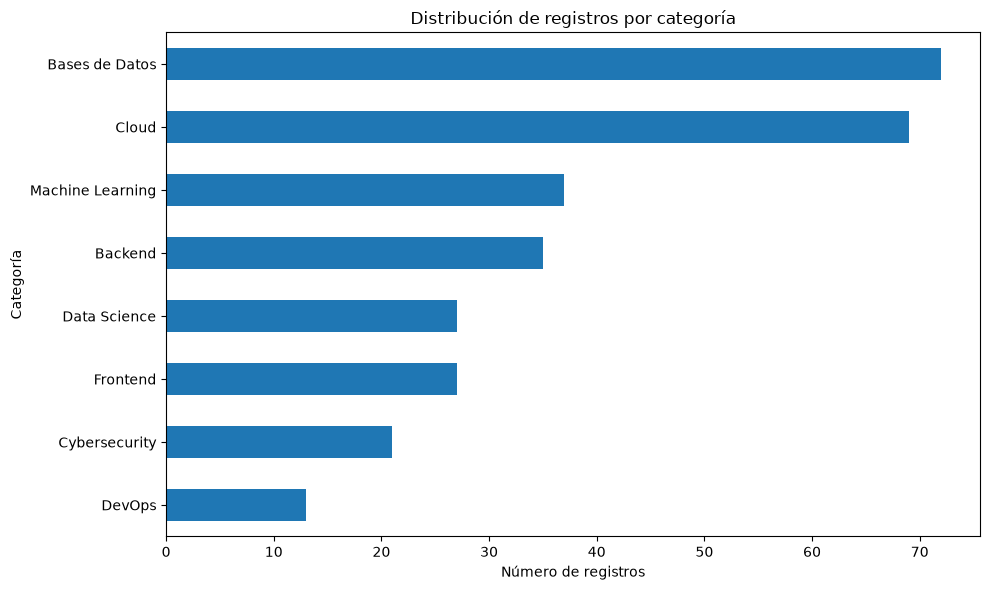

In [11]:
import matplotlib.pyplot as plt

df["categoria"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Distribución de registros por categoría")
plt.xlabel("Número de registros")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

Gráfico 2: número de tecnologías por categoría.

In [12]:
tecnologias_categoria = (
    df.groupby("categoria")["tecnologia"]
    .nunique()
    .sort_values()
)

tecnologias_categoria.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Número de tecnologías por categoría")
plt.xlabel("Número de tecnologías")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

KeyError: 'Column not found: tecnologia'

3: distribución de la longitud de los textos

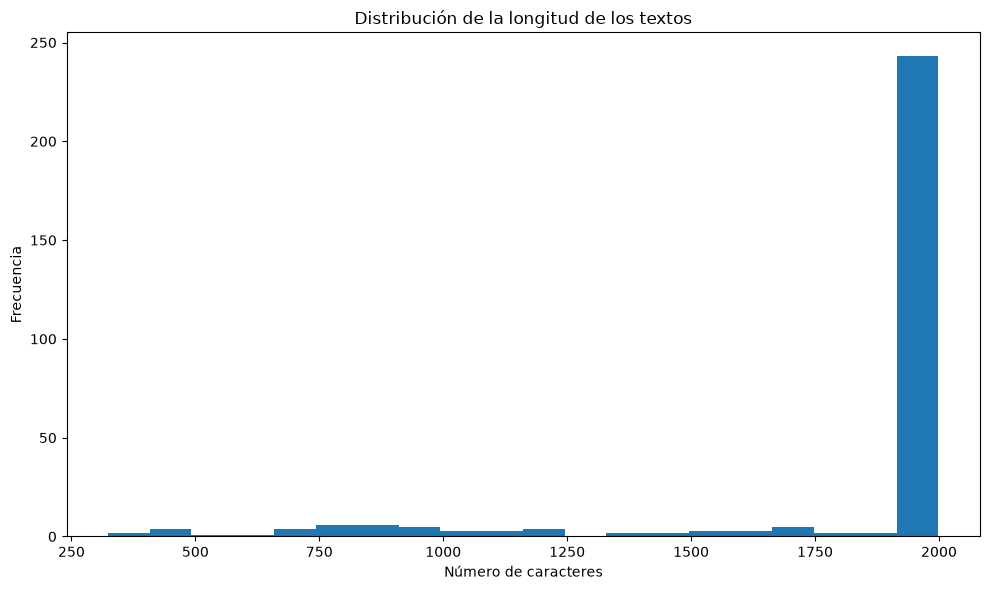

In [13]:
df["longitud_texto"].plot(
    kind="hist",
    bins=20,
    figsize=(10, 6)
)

plt.title("Distribución de la longitud de los textos")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

distribución de la longitud del texto por categoría.

<Figure size 1200x600 with 0 Axes>

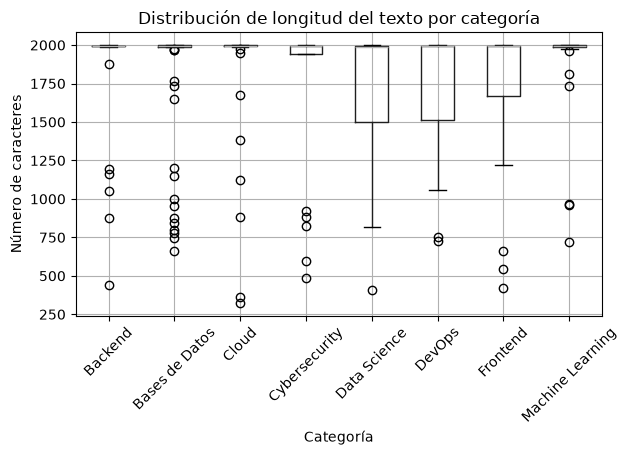

In [14]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="longitud_texto",
    by="categoria",
    rot=45
)

plt.title("Distribución de longitud del texto por categoría")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Número de caracteres")
plt.tight_layout()
plt.show()

Ahora vamos a revisar el contenido real de los textos

In [15]:
df[
    ["titulo", "categoria", "longitud_texto"]
].head(20)

,titulo,categoria,longitud_texto
0,FastAPI - FastAPI Official Docs - Parte 1,Backend,1996
1,FastAPI - FastAPI Official Docs - Parte 2,Backend,1997
2,FastAPI - FastAPI Official Docs - Parte 3,Backend,1993
3,FastAPI - FastAPI Official Docs - Parte 4,Backend,1995
4,FastAPI - FastAPI Official Docs - Parte 5,Backend,1996
5,FastAPI - FastAPI Official Docs - Parte 6,Backend,1999
6,FastAPI - FastAPI Official Docs - Parte 7,Backend,1997
7,FastAPI - FastAPI GitHub - Parte 1,Backend,1999
8,FastAPI - FastAPI GitHub - Parte 2,Backend,1988
9,FastAPI - FastAPI GitHub - Parte 3,Backend,1995


In [16]:
df[
    df["longitud_texto"] < 500
][
    ["titulo", "categoria", "texto", "longitud_texto"]
]

,titulo,categoria,texto,longitud_texto
25,Django - Django GitHub - Parte 3,Backend,this page . https://www.djangoproject.com/fund...,438
48,React - React Tutorial - Parte 7,Frontend,onClick = { handleClick } /> < MyButton count ...,424
88,Scikit-learn - Scikit-learn Tutorial - Parte 7,Data Science,compatible inputs 13.2.5. Input and output arr...,410
157,Oracle Cloud (OCI) - Oracle Cloud (OCI) Tutori...,Cloud,"YouTube channel . Additionally, visit educatio...",324
160,AWS - AWS GitHub - Parte 3,Cloud,year of commit activity C# 128 Apache-2.0 888 ...,362
236,NIST - NIST GitHub - Parte 3,Cybersecurity,model for traction lithium battery recovery Uh...,484


contar por tecnologia 

In [17]:
df["tecnologia"] = (
    df["titulo"]
    .str.split(" - ")
    .str[0]
)

df["tecnologia"].value_counts()

tecnologia
Azure                 47
Redis                 29
PyTorch               25
SQLite                24
Oracle Cloud (OCI)    19
FastAPI               18
Django                14
React                 14
OWASP                 14
Scikit-learn          13
Pandas                 9
MongoDB                9
Vue                    8
TensorFlow             7
Angular                5
NumPy                  5
Hugging Face           5
Docker                 5
NIST                   5
Kubernetes             4
GitHub Actions         4
PostgreSQL             4
MariaDB                4
NestJS                 3
AWS                    3
MySQL                  2
Kali Linux             2
Name: count, dtype: int64

In [18]:
df.groupby(
    ["categoria", "tecnologia"]
).size().sort_values(
    ascending=False
)

categoria         tecnologia        
Cloud             Azure                 47
Bases de Datos    Redis                 29
Machine Learning  PyTorch               25
Bases de Datos    SQLite                24
Cloud             Oracle Cloud (OCI)    19
Backend           FastAPI               18
                  Django                14
Cybersecurity     OWASP                 14
Frontend          React                 14
Data Science      Scikit-learn          13
Bases de Datos    MongoDB                9
Data Science      Pandas                 9
Frontend          Vue                    8
Machine Learning  TensorFlow             7
Frontend          Angular                5
Machine Learning  Hugging Face           5
DevOps            Docker                 5
Cybersecurity     NIST                   5
Data Science      NumPy                  5
Bases de Datos    MariaDB                4
DevOps            GitHub Actions         4
                  Kubernetes             4
Bases de Datos   

cuántos registros aporta cada tecnología a cada categoría

In [19]:
technology_category_table = pd.crosstab(
    df["tecnologia"],
    df["categoria"]
)

technology_category_table

categoria,Backend,Bases de Datos,Cloud,Cybersecurity,Data Science,DevOps,Frontend,Machine Learning
tecnologia,,,,,,,,
AWS,0,0,3,0,0,0,0,0
Angular,0,0,0,0,0,0,5,0
Azure,0,0,47,0,0,0,0,0
Django,14,0,0,0,0,0,0,0
Docker,0,0,0,0,0,5,0,0
FastAPI,18,0,0,0,0,0,0,0
GitHub Actions,0,0,0,0,0,4,0,0
Hugging Face,0,0,0,0,0,0,0,5
Kali Linux,0,0,0,2,0,0,0,0


In [20]:
df.groupby(
    "categoria"
)["tecnologia"].nunique()

categoria
Backend             3
Bases de Datos      6
Cloud               3
Cybersecurity       3
Data Science        3
DevOps              3
Frontend            3
Machine Learning    3
Name: tecnologia, dtype: int64

Inspeccionando titulo por categoria 

In [21]:
df.groupby("categoria")["texto"].apply(
    lambda x: " ".join(x)
).str.lower().str.split().str[:30]

categoria
Backend             [fastapi, -, fastapi, skip, to, content, fasta...
Bases de Datos      [postgresql:, documentation, july, 16,, 2026:,...
Cloud               [oracle, cloud, portal, build, gen, 2, oracle,...
Cybersecurity       [owasp, foundation,, the, open, source, founda...
Data Science        [pandas, documentation, —, pandas, 3.0.4, docu...
DevOps              [docker, docs, start, a, new, chat, when, enab...
Frontend            [react, react, the, library, for, web, and, na...
Machine Learning    [tensorflow, skip, to, main, content, /, engli...
Name: texto, dtype: object

In [22]:
for categoria in df["categoria"].unique():
    print("\n" + "=" * 60)
    print(categoria)
    print("=" * 60)

    print(
        df[df["categoria"] == categoria]["titulo"]
        .head(10)
        .to_string(index=False)
    )


Backend
FastAPI - FastAPI Official Docs - Parte 1
FastAPI - FastAPI Official Docs - Parte 2
FastAPI - FastAPI Official Docs - Parte 3
FastAPI - FastAPI Official Docs - Parte 4
FastAPI - FastAPI Official Docs - Parte 5
FastAPI - FastAPI Official Docs - Parte 6
FastAPI - FastAPI Official Docs - Parte 7
       FastAPI - FastAPI GitHub - Parte 1
       FastAPI - FastAPI GitHub - Parte 2
       FastAPI - FastAPI GitHub - Parte 3

Frontend
React - React Official Docs - Parte 1
React - React Official Docs - Parte 2
React - React Official Docs - Parte 3
React - React Official Docs - Parte 4
       React - React GitHub - Parte 1
       React - React GitHub - Parte 2
       React - React GitHub - Parte 3
     React - React Tutorial - Parte 1
     React - React Tutorial - Parte 2
     React - React Tutorial - Parte 3

Data Science
Pandas - Pandas Official Docs - Parte 1
       Pandas - Pandas GitHub - Parte 1
       Pandas - Pandas GitHub - Parte 2
       Pandas - Pandas GitHub - Parte 3
       

Creando columna de fuentes 

In [23]:
df["fuente"] = (
    df["titulo"]
    .str.split(" - ")
    .str[1]
)

In [24]:
df["tecnologia"] = (
    df["titulo"]
    .str.split(" - ")
    .str[0]
)

In [25]:
df["parte"] = (
    df["titulo"]
    .str.extract(r"Parte (\d+)")
    .astype(int)
)

In [26]:
df[
    [
        "titulo",
        "tecnologia",
        "fuente",
        "parte",
        "categoria"
    ]
].head(15)

,titulo,tecnologia,fuente,parte,categoria
0,FastAPI - FastAPI Official Docs - Parte 1,FastAPI,FastAPI Official Docs,1,Backend
1,FastAPI - FastAPI Official Docs - Parte 2,FastAPI,FastAPI Official Docs,2,Backend
2,FastAPI - FastAPI Official Docs - Parte 3,FastAPI,FastAPI Official Docs,3,Backend
3,FastAPI - FastAPI Official Docs - Parte 4,FastAPI,FastAPI Official Docs,4,Backend
4,FastAPI - FastAPI Official Docs - Parte 5,FastAPI,FastAPI Official Docs,5,Backend
5,FastAPI - FastAPI Official Docs - Parte 6,FastAPI,FastAPI Official Docs,6,Backend
6,FastAPI - FastAPI Official Docs - Parte 7,FastAPI,FastAPI Official Docs,7,Backend
7,FastAPI - FastAPI GitHub - Parte 1,FastAPI,FastAPI GitHub,1,Backend
8,FastAPI - FastAPI GitHub - Parte 2,FastAPI,FastAPI GitHub,2,Backend
9,FastAPI - FastAPI GitHub - Parte 3,FastAPI,FastAPI GitHub,3,Backend


crear el texto de entrenamiento, para el primer modelo, vamos a combinar el título y el contenido

In [27]:
df["texto_modelo"] = (
    df["titulo"].fillna("")
    + " "
    + df["texto"].fillna("")
)

In [28]:
df[
    ["titulo", "texto_modelo", "categoria"]
].head(2)

,titulo,texto_modelo,categoria
0,FastAPI - FastAPI Official Docs - Parte 1,FastAPI - FastAPI Official Docs - Parte 1 Fast...,Backend
1,FastAPI - FastAPI Official Docs - Parte 2,FastAPI - FastAPI Official Docs - Parte 2 woul...,Backend


1: separar datos de entrenamiento y prueba

In [29]:
from sklearn.model_selection import train_test_split

X = df["texto_modelo"]
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

Registros de entrenamiento: 240
Registros de prueba: 61


In [30]:
import sys

print(sys.executable)

C:\Proyectos\TechMind-DS\.venv\Scripts\python.exe


In [31]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


2: transformar el texto con TF-IDF

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Forma de X_train:", X_train_tfidf.shape)
print("Forma de X_test:", X_test_tfidf.shape)

Forma de X_train: (240, 5000)
Forma de X_test: (61, 5000)


3: entrenar el primer modelo

In [33]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo.fit(
    X_train_tfidf,
    y_train
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


4: Prediccion 

In [34]:
y_pred = modelo.predict(X_test_tfidf)

print(y_pred[:10])

['Frontend' 'Bases de Datos' 'Cybersecurity' 'Bases de Datos' 'Backend'
 'Backend' 'Machine Learning' 'Backend' 'Bases de Datos' 'Cybersecurity']


Matricas

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8852


In [36]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

                  precision    recall  f1-score   support

         Backend       1.00      0.71      0.83         7
  Bases de Datos       1.00      0.87      0.93        15
           Cloud       0.93      0.93      0.93        14
   Cybersecurity       0.50      0.75      0.60         4
    Data Science       1.00      1.00      1.00         5
          DevOps       0.60      1.00      0.75         3
        Frontend       0.83      1.00      0.91         5
Machine Learning       1.00      0.88      0.93         8

        accuracy                           0.89        61
       macro avg       0.86      0.89      0.86        61
    weighted avg       0.92      0.89      0.89        61



Que casos confunden al modelo actualmente, Matriz de confucion para indicar los errores  

In [37]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=modelo.classes_
)

cm_df = pd.DataFrame(
    cm,
    index=modelo.classes_,
    columns=modelo.classes_
)

cm_df

,Backend,Bases de Datos,Cloud,Cybersecurity,Data Science,DevOps,Frontend,Machine Learning
Backend,5,0,0,1,0,0,1,0
Bases de Datos,0,13,0,1,0,1,0,0
Cloud,0,0,13,1,0,0,0,0
Cybersecurity,0,0,1,3,0,0,0,0
Data Science,0,0,0,0,5,0,0,0
DevOps,0,0,0,0,0,3,0,0
Frontend,0,0,0,0,0,0,5,0
Machine Learning,0,0,0,0,0,1,0,7


In [38]:
errores = df.loc[
    X_test.index[y_test != y_pred],
    [
        "titulo",
        "tecnologia",
        "categoria",
        "texto"
    ]
].copy()

errores["prediccion"] = y_pred[y_test != y_pred]

errores[
    [
        "titulo",
        "tecnologia",
        "categoria",
        "prediccion"
    ]
]

,titulo,tecnologia,categoria,prediccion
25,Django - Django GitHub - Parte 3,Django,Backend,Cybersecurity
124,Hugging Face - Hugging Face GitHub - Parte 2,Hugging Face,Machine Learning,DevOps
210,PostgreSQL - PostgreSQL GitHub - Parte 2,PostgreSQL,Bases de Datos,Cybersecurity
237,Kali Linux - Kali Linux Official Docs - Parte 1,Kali Linux,Cybersecurity,Cloud
216,MongoDB - MongoDB GitHub - Parte 1,MongoDB,Bases de Datos,DevOps
143,Oracle Cloud (OCI) - Oracle Cloud (OCI) GitHub...,Oracle Cloud (OCI),Cloud,Cybersecurity
34,NestJS - NestJS GitHub - Parte 3,NestJS,Backend,Frontend


In [39]:
PRUEBA CON UN SEGUNDO MODELO

SyntaxError: invalid syntax (2707414280.py, line 1)

In [ ]:
X_solo_texto = df["texto"].fillna("")

In [ ]:
X_train_texto, X_test_texto, y_train_texto, y_test_texto = train_test_split(
    X_solo_texto,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
vectorizer_texto = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_texto_tfidf = vectorizer_texto.fit_transform(X_train_texto)
X_test_texto_tfidf = vectorizer_texto.transform(X_test_texto)

ENTRENAMIENTO

In [ ]:
modelo_texto = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo_texto.fit(
    X_train_texto_tfidf,
    y_train_texto
)

y_pred_texto = modelo_texto.predict(
    X_test_texto_tfidf
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_texto,
        y_pred_texto
    )
)

evaluación por tecnología

In [ ]:
tecnologias_por_categoria = (
    df.groupby("categoria")["tecnologia"]
    .unique()
)

tecnologias_por_categoria

evaluación más equilibrada:

In [ ]:
tecnologias_test = {
    "Backend": ["NestJS"],
    "Bases de Datos": ["SQLite", "MariaDB"],
    "Cloud": ["AWS"],
    "Cybersecurity": ["Kali Linux"],
    "Data Science": ["NumPy"],
    "DevOps": ["GitHub Actions"],
    "Frontend": ["Angular"],
    "Machine Learning": ["Hugging Face"]
}

In [ ]:
creamos una máscara para identificar los registros de prueba:

In [ ]:
mask_test = df.apply(
    lambda fila: fila["tecnologia"]
    in tecnologias_test[fila["categoria"]],
    axis=1
)

In [ ]:
df_test_generalizacion = df[mask_test].copy()
df_train_generalizacion = df[~mask_test].copy()

print(
    "Registros de entrenamiento:",
    len(df_train_generalizacion)
)

print(
    "Registros de prueba:",
    len(df_test_generalizacion)
)

In [ ]:
set(
    df_train_generalizacion["tecnologia"]
).intersection(
    set(df_test_generalizacion["tecnologia"])
)

preparar los datos

In [ ]:
X_train_gen = (
    df_train_generalizacion["titulo"].fillna("")
    + " "
    + df_train_generalizacion["texto"].fillna("")
)

y_train_gen = df_train_generalizacion["categoria"]

X_test_gen = (
    df_test_generalizacion["titulo"].fillna("")
    + " "
    + df_test_generalizacion["texto"].fillna("")
)

y_test_gen = df_test_generalizacion["categoria"]

In [ ]:
print("Categorías en entrenamiento:")
print(y_train_gen.value_counts())

print("\nCategorías en prueba:")
print(y_test_gen.value_counts())

1: TF-IDF para generalización

In [ ]:
vectorizer_gen = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_gen_tfidf = vectorizer_gen.fit_transform(X_train_gen)
X_test_gen_tfidf = vectorizer_gen.transform(X_test_gen)

print("Forma de entrenamiento:", X_train_gen_tfidf.shape)
print("Forma de prueba:", X_test_gen_tfidf.shape)

2: entrenar el modelo

In [ ]:
modelo_gen = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo_gen.fit(
    X_train_gen_tfidf,
    y_train_gen
)

print("Modelo de generalización entrenado")

In [ ]:
y_pred_gen = modelo_gen.predict(
    X_test_gen_tfidf
)

print(y_pred_gen[:10])

In [ ]:
accuracy_gen = accuracy_score(
    y_test_gen,
    y_pred_gen
)

print(
    f"Accuracy generalización: {accuracy_gen:.4f}"
)

In [ ]:
print(
    classification_report(
        y_test_gen,
        y_pred_gen
    )
)

distribuyen las predicciones de la evaluación de generalización:

In [ ]:
pd.Series(y_pred_gen).value_counts()

Evaluación por documento original

In [ ]:
df.groupby(
    ["categoria", "tecnologia", "fuente"]
).size()

In [ ]:
df["fuente"].nunique()

Vamos a dividir por fuente completa.

In [ ]:
fuentes_por_categoria = (
    df.groupby("categoria")["fuente"]
    .nunique()
    .sort_values()
)

fuentes_por_categoria

In [ ]:
df.groupby(
    ["categoria", "fuente"]
).size()

evaluacion, 1: crear la división por fuente 

In [ ]:
import numpy as np

np.random.seed(42)

fuentes_train = []
fuentes_test = []

for categoria, grupo in df.groupby("categoria"):
    
    fuentes = grupo["fuente"].unique().tolist()
    
    np.random.shuffle(fuentes)
    
    n_test = max(2, round(len(fuentes) * 0.30))
    
    fuentes_test_categoria = fuentes[:n_test]
    fuentes_train_categoria = fuentes[n_test:]
    
    fuentes_test.extend(fuentes_test_categoria)
    fuentes_train.extend(fuentes_train_categoria)

print("Fuentes de entrenamiento:", len(fuentes_train))
print("Fuentes de prueba:", len(fuentes_test))

2: crear los datasets

In [ ]:
df_train_fuente = df[
    df["fuente"].isin(fuentes_train)
].copy()

df_test_fuente = df[
    df["fuente"].isin(fuentes_test)
].copy()

print("Registros de entrenamiento:", len(df_train_fuente))
print("Registros de prueba:", len(df_test_fuente))

3: verificar que no hay fuga de información

In [ ]:
interseccion_fuentes = set(
    df_train_fuente["fuente"]
).intersection(
    set(df_test_fuente["fuente"])
)

print(interseccion_fuentes)

4: revisar el balance

In [ ]:
print("TRAIN")
print(
    df_train_fuente["categoria"].value_counts()
)

print("\nTEST")
print(
    df_test_fuente["categoria"].value_counts()
)

In [ ]:
print("FUENTES TRAIN POR CATEGORÍA")
print(
    df_train_fuente.groupby("categoria")["fuente"]
    .nunique()
)

print("\nFUENTES TEST POR CATEGORÍA")
print(
    df_test_fuente.groupby("categoria")["fuente"]
    .nunique()
)

vamos a balancear 

In [ ]:
df.groupby(
    ["categoria", "tecnologia"]
).size().sort_values()

Tabla de control

In [ ]:
objetivo = 40

resumen_balance = (
    df["categoria"]
    .value_counts()
    .rename("actual")
    .to_frame()
)

resumen_balance["objetivo"] = objetivo

resumen_balance["faltan"] = (
    resumen_balance["objetivo"]
    - resumen_balance["actual"]
).clip(lower=0)

resumen_balance.sort_values("actual")

plan de nuevas fuentes 

In [ ]:
plan_nuevas_tecnologias = pd.DataFrame({
    "categoria": [
        "DevOps", "DevOps", "DevOps", "DevOps",
        "Cybersecurity", "Cybersecurity", "Cybersecurity", "Cybersecurity",
        "Frontend", "Frontend", "Frontend",
        "Data Science", "Data Science", "Data Science",
        "Backend",
        "Machine Learning"
    ],
    "tecnologia": [
        "Jenkins", "Terraform", "Ansible", "GitLab CI/CD",
        "Wireshark", "Metasploit", "MITRE ATT&CK", "Burp Suite",
        "Next.js", "Svelte", "Astro",
        "Matplotlib", "SciPy", "Jupyter",
        "Express.js",
        "XGBoost"
    ]
})

plan_nuevas_tecnologias

In [ ]:
df_topics = pd.read_csv(
    "../data/external/topics.csv"
)

df_topics.tail(20)

In [ ]:
topics = pd.read_csv(
    r"C:\Proyectos\TechMind-DS\data\external\topics.csv"
)

print(topics.shape)
print(topics.columns.tolist())
print(topics.tail(20))

In [ ]:
topics.groupby("categoria")["tecnologia"].nunique()

In [ ]:
LIMPIANDO NUESTRO DATASET 

In [ ]:
topics.columns = topics.columns.str.strip()

# Eliminar duplicados por categoría y tecnología
topics = topics.drop_duplicates(
    subset=["categoria", "tecnologia"],
    keep="first"
)

# Corregir URL de AWS
topics.loc[
    topics["tecnologia"] == "AWS",
    "tutorial"
] = "https://aws.amazon.com/getting-started/"

print("Tecnologías únicas:", topics["tecnologia"].nunique())
print(topics.groupby("categoria")["tecnologia"].nunique())

AGREGANDO NUEVAS TECNOLOGIAS PARA BALANCEAR 

In [40]:
nuevas_tecnologias = pd.DataFrame({
    "id": range(
        topics["id"].max() + 1,
        topics["id"].max() + 17
    ),
    "categoria": [
        "DevOps", "DevOps", "DevOps", "DevOps",
        "Cybersecurity", "Cybersecurity", "Cybersecurity", "Cybersecurity",
        "Frontend", "Frontend", "Frontend",
        "Data Science", "Data Science", "Data Science",
        "Backend",
        "Machine Learning"
    ],
    "tecnologia": [
        "Jenkins", "Terraform", "Ansible", "GitLab CI/CD",
        "Wireshark", "Metasploit", "MITRE ATT&CK", "Burp Suite",
        "Next.js", "Svelte", "Astro",
        "Matplotlib", "SciPy", "Jupyter",
        "Express.js",
        "XGBoost"
    ],
    "sitio_oficial": [
        "https://www.jenkins.io/doc/",
        "https://developer.hashicorp.com/terraform/docs",
        "https://docs.ansible.com/",
        "https://docs.gitlab.com/ee/ci/",
        "https://www.wireshark.org/docs/",
        "https://docs.metasploit.com/",
        "https://attack.mitre.org/",
        "https://portswigger.net/burp/documentation",
        "https://nextjs.org/docs",
        "https://svelte.dev/docs",
        "https://docs.astro.build/",
        "https://matplotlib.org/stable/",
        "https://docs.scipy.org/doc/scipy/",
        "https://jupyter.org/documentation",
        "https://expressjs.com/",
        "https://xgboost.readthedocs.io/"
    ],
    "github": [
        "https://github.com/jenkinsci/jenkins",
        "https://github.com/hashicorp/terraform",
        "https://github.com/ansible/ansible",
        "https://gitlab.com/gitlab-org/gitlab",
        "https://github.com/wireshark/wireshark",
        "https://github.com/rapid7/metasploit-framework",
        "https://github.com/mitre-attack/attack-stix-data",
        "https://github.com/PortSwigger",
        "https://github.com/vercel/next.js",
        "https://github.com/sveltejs/svelte",
        "https://github.com/withastro/astro",
        "https://github.com/matplotlib/matplotlib",
        "https://github.com/scipy/scipy",
        "https://github.com/jupyter/notebook",
        "https://github.com/expressjs/express",
        "https://github.com/dmlc/xgboost"
    ],
    "tutorial": [
        "https://www.jenkins.io/doc/tutorials/",
        "https://developer.hashicorp.com/terraform/tutorials",
        "https://docs.ansible.com/ansible/latest/getting_started/",
        "https://docs.gitlab.com/ee/ci/quick_start/",
        "https://www.wireshark.org/docs/wsug_html_chunked/",
        "https://docs.metasploit.com/",
        "https://attack.mitre.org/resources/",
        "https://portswigger.net/web-security",
        "https://nextjs.org/learn",
        "https://svelte.dev/tutorial/",
        "https://docs.astro.build/en/tutorial/",
        "https://matplotlib.org/stable/tutorials/",
        "https://docs.scipy.org/doc/scipy/tutorial/",
        "https://docs.jupyter.org/en/latest/",
        "https://expressjs.com/en/starter/installing.html",
        "https://xgboost.readthedocs.io/en/stable/tutorials/"
    ]
})

nuevas_tecnologias

NameError: name 'topics' is not defined

In [ ]:
topics_ampliado = pd.concat(
    [topics, nuevas_tecnologias],
    ignore_index=True
)

print("Total de tecnologías:",
      topics_ampliado["tecnologia"].nunique())

print("\nDistribución:")
print(
    topics_ampliado.groupby("categoria")["tecnologia"]
    .nunique()
)

REMPLAZANDO

In [ ]:
topics_ampliado.to_csv(
    r"C:\Proyectos\TechMind-DS\data\external\topics.csv",
    index=False,
    encoding="utf-8-sig"
)

print(" topics.csv actualizado correctamente")
print(f" Filas: {len(topics_ampliado)}")
print(f" Tecnologías únicas: {topics_ampliado['tecnologia'].nunique()}")

In [ ]:
topics_verificacion = pd.read_csv(
    r"C:\Proyectos\TechMind-DS\data\external\topics.csv"
)

topics_verificacion.columns = topics_verificacion.columns.str.strip()

print(topics_verificacion.shape)
print(topics_verificacion.groupby("categoria")["tecnologia"].nunique())

In [ ]:
import pandas as pd

sources_validated = pd.read_csv(
    r"C:\Proyectos\TechMind-DS\data\external\sources_validated.csv"
)

print(sources_validated.columns.tolist())

In [ ]:
sources_validated[
    sources_validated["accessible"] == False
][
    ["categoria", "tecnologia", "tipo", "url"]
]

REPARAR FUENTES 

In [41]:
topics_ampliado.loc[
    topics_ampliado["tecnologia"] == "MySQL",
    "sitio_oficial"
] = "https://www.mysql.com/"

topics_ampliado.loc[
    topics_ampliado["tecnologia"] == "MySQL",
    "tutorial"
] = "https://www.mysqltutorial.org/"

NameError: name 'topics_ampliado' is not defined

In [ ]:
topics_ampliado.to_csv(
    r"C:\Proyectos\TechMind-DS\data\external\topics.csv",
    index=False,
    encoding="utf-8-sig"
)

IDENTIFICANDO FUENTES FALSAS 

In [ ]:
sources_validated[
    sources_validated["accessible"] == False
][
    ["categoria", "tecnologia", "tipo", "url"]
]

In [ ]:
sources_validated = pd.read_csv(
    r"C:\Proyectos\TechMind-DS\data\external\sources_validated.csv"
)

In [ ]:
# Verificar la última fuente no accesible

sources_validated[
    sources_validated["accessible"] == False
][
    ["categoria", "tecnologia", "tipo", "url"]
]

In [ ]:
import pandas as pd

raw_docs = pd.read_csv(
    r"C:\Proyectos\TechMind-DS\data\raw\raw_documents.csv"
)

print(raw_docs.shape)
print(raw_docs.columns.tolist())
raw_docs.head()

In [ ]:
raw_docs.info()

In [ ]:
raw_docs["categoria"].value_counts()

In [ ]:
raw_docs.groupby(
    ["categoria", "tecnologia"]
).size()

In [ ]:
raw_docs.groupby(
    ["categoria", "tipo"]
).size()

In [ ]:
dataset_old = pd.read_csv(
    r"C:\Proyectos\TechMind-DS\data\processed\dataset.csv"
)

In [ ]:
dataset_old = pd.read_csv(
    r"C:\Proyectos\TechMind-DS\data\processed\dataset.csv"
)

print("Dataset anterior:", dataset_old.shape)
print("Dataset nuevo:", raw_docs.shape)

In [42]:
dataset_old.head()

NameError: name 'dataset_old' is not defined

In [ ]:
raw_docs.head()

In [43]:
raw_docs["longitud_texto"].describe()


NameError: name 'raw_docs' is not defined

In [ ]:
raw_docs.groupby("categoria")["longitud_texto"].agg(
    ["count", "mean", "median", "min", "max"]
).round(0)

In [ ]:
raw_docs.sort_values(
    "longitud_texto"
)[
    ["categoria", "tecnologia", "titulo", "longitud_texto"]
].head(15)

In [ ]:
# ============================================
# CONSTRUCCIÓN DEL DATASET FINAL
# ============================================

import pandas as pd
import re

# Copia del dataset nuevo
docs = raw_docs.copy()

# --------------------------------------------
# 1. Limpiar textos
# --------------------------------------------

docs["texto"] = (
    docs["texto"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# --------------------------------------------
# 2. Eliminar documentos demasiado pequeños
# --------------------------------------------

docs = docs[
    docs["longitud_texto"] >= 1000
].copy()

print("Documentos después del filtro:", len(docs))

In [ ]:
docs[
    ["categoria", "tecnologia", "titulo", "longitud_texto"]
].sort_values("longitud_texto").head(10)

In [ ]:
print("Documentos originales:", len(raw_docs))
print("Documentos después del filtro:", len(docs))

In [ ]:
docs["categoria"].value_counts().sort_index()

In [ ]:
docs.groupby(
    ["categoria", "tecnologia"]
).size()

In [ ]:
# ============================================
# FRAGMENTACIÓN DE DOCUMENTOS
# ============================================

def dividir_texto(texto, tamano=1500, solapamiento=200):
    fragmentos = []

    inicio = 0
    longitud = len(texto)

    while inicio < longitud:
        fin = inicio + tamano

        fragmento = texto[inicio:fin].strip()

        if len(fragmento) >= 500:
            fragmentos.append(fragmento)

        inicio = fin - solapamiento

    return fragmentos

In [ ]:
fragmentos = []

for _, fila in docs.iterrows():

    partes = dividir_texto(
        fila["texto"],
        tamano=1500,
        solapamiento=200
    )

    for i, parte in enumerate(partes, start=1):

        fragmentos.append({
            "titulo": f'{fila["tecnologia"]} - {fila["titulo"]} - Parte {i}',
            "texto": parte,
            "categoria": fila["categoria"],
            "tecnologia": fila["tecnologia"],
            "tipo": fila["tipo"],
            "url": fila["url"]
        })

dataset_nuevo = pd.DataFrame(fragmentos)

print("Fragmentos generados:", len(dataset_nuevo))

In [ ]:
dataset_nuevo.groupby("categoria").size()

In [ ]:
dataset_nuevo.groupby(
    ["categoria", "tecnologia"]
).size()

In [ ]:
# ============================================
# CREAR DATASET FINAL BALANCEADO
# ============================================

N_POR_CATEGORIA = 49

dataset_final = (
    dataset_nuevo
    .groupby("categoria", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=N_POR_CATEGORIA,
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print("Registros finales:", len(dataset_final))

In [ ]:
dataset_final["categoria"].value_counts()

In [ ]:
# Revisar estructura actual
print(dataset_final.shape)
print(dataset_final.columns)
print(dataset_final.index.names)

In [ ]:
# Convertir el índice categoria en columna
dataset_final = dataset_final.reset_index()

# Verificar columnas
print(dataset_final.columns)

In [ ]:
dataset_final["categoria"].value_counts()

In [44]:
topics.columns.tolist()

NameError: name 'topics' is not defined

In [ ]:
import pandas as pd

In [ ]:
topics = pd.read_csv(
    "../data/external/topics.csv"
)

In [ ]:
topics.columns.tolist()

In [ ]:
topics.columns = topics.columns.str.strip()

In [ ]:
tecnologia_categoria = (
    topics
    .drop_duplicates("tecnologia")
    .set_index("tecnologia")["categoria"]
    .to_dict()
)

dataset_final["categoria"] = dataset_final["tecnologia"].map(
    tecnologia_categoria
)

In [ ]:
print(dataset_final.shape)
print(dataset_final.columns.tolist())
print(dataset_final["categoria"].value_counts())
print("\nCategorías faltantes:")
print(dataset_final["categoria"].isna().sum())

In [ ]:
dataset_final = dataset_final.drop(
    columns=["index"]
)

In [ ]:
dataset_final.columns.tolist()

In [ ]:
dataset_final.to_csv(
    "../data/processed/dataset_final.csv",
    index=False,
    encoding="utf-8"
)

In [ ]:
# Eliminar índice antiguo
dataset_final = dataset_final.drop(
    columns=["index"],
    errors="ignore"
)

# Guardar dataset final
dataset_final.to_csv(
    "../data/processed/dataset_final.csv",
    index=False,
    encoding="utf-8"
)

print(" Dataset final guardado correctamente")
print(" Registros:", len(dataset_final))
print(" Columnas:", dataset_final.columns.tolist())

In [ ]:
dataset_check = pd.read_csv(
    "../data/processed/dataset_final.csv"
)

print(dataset_check.shape)
print(dataset_check["categoria"].value_counts())

In [45]:
dataset_final = pd.read_csv(
    "../data/processed/dataset_final.csv"
)

print(dataset_final.shape)
print(dataset_final.columns)
print(dataset_final["categoria"].value_counts())

(392, 6)
Index(['titulo', 'texto', 'tecnologia', 'tipo', 'url', 'categoria'], dtype='str')
categoria
Backend             49
Bases de Datos      49
Cloud               49
Cybersecurity       49
Data Science        49
DevOps              49
Frontend            49
Machine Learning    49
Name: count, dtype: int64


# ==========================================
# ENTRENAMIENTO DEL MODELO FINAL
# ==========================================

Paso 1: separar las variables

In [46]:
# Variable de entrada
X = dataset_final["texto"]

# Variable objetivo
y = dataset_final["categoria"]

print("Registros totales:", len(dataset_final))
print("Variable X:", X.shape)
print("Variable y:", y.shape)

Registros totales: 392
Variable X: (392,)
Variable y: (392,)


vamos a dividir el dataset en entrenamiento y prueba usaremos 80% para entrenar y 20% para evaluar, manteniendo las 8 categorías equilibradas mediante stratify=y.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

print("\nCategorías en entrenamiento:")
print(y_train.value_counts().sort_index())

print("\nCategorías en prueba:")
print(y_test.value_counts().sort_index())

Registros de entrenamiento: 313
Registros de prueba: 79

Categorías en entrenamiento:
categoria
Backend             39
Bases de Datos      40
Cloud               39
Cybersecurity       39
Data Science        39
DevOps              39
Frontend            39
Machine Learning    39
Name: count, dtype: int64

Categorías en prueba:
categoria
Backend             10
Bases de Datos       9
Cloud               10
Cybersecurity       10
Data Science        10
DevOps              10
Frontend            10
Machine Learning    10
Name: count, dtype: int64


TF-IDF transforma las palabras en valores numéricos según su importancia dentro de los documentos, texto convertido correctamente en una matriz numérica

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Forma de X_train:", X_train_tfidf.shape)
print("Forma de X_test:", X_test_tfidf.shape)

Forma de X_train: (313, 5000)
Forma de X_test: (79, 5000)


entrenaremos el modelo de clasificación, para este tipo de problema de clasificación de textos, empezaremos con Logistic Regression, que suele funcionar muy bien junto con TF-IDF

In [49]:
# ==========================================
# ENTRENAMIENTO DEL MODELO FINAL
# ==========================================

from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_tfidf, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


Generar las predicciones sobre los 79 registros de prueba y medir su rendimiento

In [50]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

# Reporte completo
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9494

Reporte de clasificación:
                  precision    recall  f1-score   support

         Backend       1.00      0.90      0.95        10
  Bases de Datos       1.00      0.89      0.94         9
           Cloud       1.00      1.00      1.00        10
   Cybersecurity       0.89      0.80      0.84        10
    Data Science       0.91      1.00      0.95        10
          DevOps       0.83      1.00      0.91        10
        Frontend       1.00      1.00      1.00        10
Machine Learning       1.00      1.00      1.00        10

        accuracy                           0.95        79
       macro avg       0.95      0.95      0.95        79
    weighted avg       0.95      0.95      0.95        79



analizar qué errores comete mediante la matriz de confusión

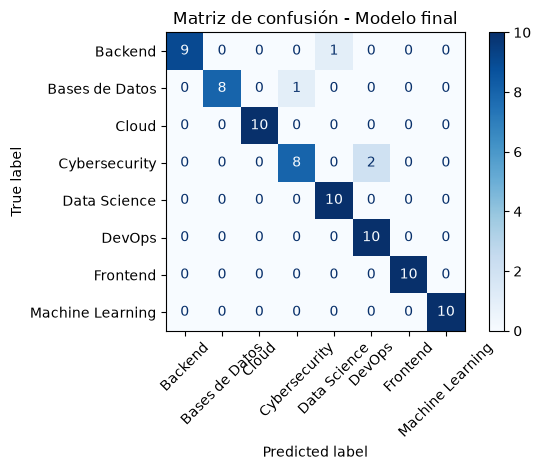

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrarla
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Matriz de confusión - Modelo final")
plt.tight_layout()
plt.show()

# ==========================================
# PRUEBA DE GENERALIZACIÓN
# ==========================================

In [52]:
textos_nuevos = [
    "FastAPI is a modern Python web framework for building APIs with automatic documentation.",
    "PostgreSQL is a powerful open source relational database system.",
    "AWS provides cloud computing services including compute, storage and databases.",
    "OWASP provides resources and standards for improving web application security.",
    "Pandas is a Python library for data manipulation and analysis.",
    "Docker packages applications and their dependencies into lightweight containers.",
    "React is a JavaScript library for building user interfaces.",
    "PyTorch is an open source machine learning framework for deep learning."
]

categorias_reales = [
    "Backend",
    "Bases de Datos",
    "Cloud",
    "Cybersecurity",
    "Data Science",
    "DevOps",
    "Frontend",
    "Machine Learning"
]

transformamos estos textos con el mismo vectorizador, sin volver a hacer fit

In [53]:
X_nuevos_tfidf = vectorizer.transform(textos_nuevos)

y_pred_nuevos = modelo.predict(X_nuevos_tfidf)

for texto, real, prediccion in zip(
    textos_nuevos,
    categorias_reales,
    y_pred_nuevos
):
    print(f"Real: {real}")
    print(f"Predicción: {prediccion}")
    print("-" * 50)

Real: Backend
Predicción: Backend
--------------------------------------------------
Real: Bases de Datos
Predicción: Bases de Datos
--------------------------------------------------
Real: Cloud
Predicción: Cloud
--------------------------------------------------
Real: Cybersecurity
Predicción: Cybersecurity
--------------------------------------------------
Real: Data Science
Predicción: Data Science
--------------------------------------------------
Real: DevOps
Predicción: DevOps
--------------------------------------------------
Real: Frontend
Predicción: Frontend
--------------------------------------------------
Real: Machine Learning
Predicción: Machine Learning
--------------------------------------------------


# ==========================================
# GUARDADO DE ARTEFACTOS DEL MODELO
# ==========================================

1. Crear la carpeta models

In [54]:
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

print(f"Carpeta creada: {MODELS_DIR.resolve()}")

Carpeta creada: C:\Proyectos\TechMind-DS\models


2. Guardar el modelo y el vectorizador

In [55]:
import joblib

joblib.dump(
    modelo,
    MODELS_DIR / "modelo_clasificador.pkl"
)

joblib.dump(
    vectorizer,
    MODELS_DIR / "vectorizador_tfidf.pkl"
)

print(" Modelo guardado correctamente")
print(" Vectorizador guardado correctamente")

 Modelo guardado correctamente
 Vectorizador guardado correctamente


3. Verificar que existen

In [56]:
print(list(MODELS_DIR.iterdir()))

[WindowsPath('../models/modelo_clasificador.pkl'), WindowsPath('../models/vectorizador_tfidf.pkl')]


1. Cargar nuevamente el modelo y el vectorizador

In [57]:
import joblib

modelo_cargado = joblib.load(
    "../models/modelo_clasificador.pkl"
)

vectorizer_cargado = joblib.load(
    "../models/vectorizador_tfidf.pkl"
)

print(" Modelo cargado correctamente")
print("Vectorizador cargado correctamente")

 Modelo cargado correctamente
Vectorizador cargado correctamente


2. Hacer una predicción con los artefactos cargados

In [58]:
texto_prueba = [
    "I am building a REST API using FastAPI and Python"
]

texto_vectorizado = vectorizer_cargado.transform(texto_prueba)

prediccion = modelo_cargado.predict(texto_vectorizado)

print("Texto:", texto_prueba[0])
print("Categoría predicha:", prediccion[0])

Texto: I am building a REST API using FastAPI and Python
Categoría predicha: Backend


In [59]:
# ==========================================
# RESUMEN FINAL DEL PROYECTO
# ==========================================

print("=" * 60)
print("RESUMEN FINAL - TECHMIND")
print("=" * 60)

print(f"\nDataset final: {len(dataset_final)} registros")
print(f"Categorías: {dataset_final['categoria'].nunique()}")
print(f"Registros de entrenamiento: {len(X_train)}")
print(f"Registros de prueba: {len(X_test)}")

print("\nDistribución del dataset:")
print(dataset_final["categoria"].value_counts().sort_index())

print(f"\nAccuracy del modelo: {accuracy:.4f}")

RESUMEN FINAL - TECHMIND

Dataset final: 392 registros
Categorías: 8
Registros de entrenamiento: 313
Registros de prueba: 79

Distribución del dataset:
categoria
Backend             49
Bases de Datos      49
Cloud               49
Cybersecurity       49
Data Science        49
DevOps              49
Frontend            49
Machine Learning    49
Name: count, dtype: int64

Accuracy del modelo: 0.9494


In [60]:
print("""
CONCLUSIONES

1. El dataset final contiene 392 registros distribuidos en 8 categorías.
2. El dataset está balanceado con 49 registros por categoría.
3. Se utilizó TF-IDF para representar los textos numéricamente.
4. Se entrenó un modelo Logistic Regression.
5. El modelo obtuvo un accuracy de 94.94% en el conjunto de prueba.
6. El F1-score macro fue de 0.95.
7. La matriz de confusión mostró únicamente 4 errores en 79 documentos.
8. Los artefactos del modelo fueron guardados para su reutilización.
9. Se realizó una prueba adicional con 8 textos nuevos, obteniendo 8/8 predicciones correctas.
""")


CONCLUSIONES

1. El dataset final contiene 392 registros distribuidos en 8 categorías.
2. El dataset está balanceado con 49 registros por categoría.
3. Se utilizó TF-IDF para representar los textos numéricamente.
4. Se entrenó un modelo Logistic Regression.
5. El modelo obtuvo un accuracy de 94.94% en el conjunto de prueba.
6. El F1-score macro fue de 0.95.
7. La matriz de confusión mostró únicamente 4 errores en 79 documentos.
8. Los artefactos del modelo fueron guardados para su reutilización.
9. Se realizó una prueba adicional con 8 textos nuevos, obteniendo 8/8 predicciones correctas.

